In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)

df = pd.read_stata(
    r'C:\\Users\\honor\\Downloads\\GSS_stata\\gss7224_r2.dta',
    convert_categoricals=False
)

print(df.head())

   year  id  wrkstat  hrs1  hrs2  evwork    occ  prestige  wrkslf  wrkgovt  \
0  1972   1      1.0   NaN   NaN     NaN  205.0      50.0     2.0      NaN   
1  1972   2      5.0   NaN   NaN     1.0  441.0      45.0     2.0      NaN   
2  1972   3      2.0   NaN   NaN     NaN  270.0      44.0     2.0      NaN   
3  1972   4      1.0   NaN   NaN     NaN    1.0      57.0     2.0      NaN   
4  1972   5      7.0   NaN   NaN     1.0  385.0      40.0     2.0      NaN   

   commute  industry  occ80  prestg80  indus80  indus07  occonet  found  \
0      NaN     609.0    NaN       NaN      NaN      NaN      NaN    1.0   
1      NaN     338.0    NaN       NaN      NaN      NaN      NaN    1.0   
2      NaN     718.0    NaN       NaN      NaN      NaN      NaN    0.0   
3      NaN     319.0    NaN       NaN      NaN      NaN      NaN    1.0   
4      NaN     448.0    NaN       NaN      NaN      NaN      NaN    1.0   

    occ10  occindv  occstatus  occtag  prestg10  prestg105plus  indus10  \
0   5

In [2]:
df_96 = df.loc[df["year"] >= 1996]          # no copy
# or if you really need a copy of the slice:
# df_96 = df.loc[df["year"] >= 1996].copy(deep=False)  # shallow copy

In [3]:
df_96["year"].describe()

count    43319.000000
mean      2010.447933
std          9.061920
min       1996.000000
25%       2002.000000
50%       2010.000000
75%       2021.000000
max       2024.000000
Name: year, dtype: float64

In [4]:
print(df.columns.tolist())

['year', 'id', 'wrkstat', 'hrs1', 'hrs2', 'evwork', 'occ', 'prestige', 'wrkslf', 'wrkgovt', 'commute', 'industry', 'occ80', 'prestg80', 'indus80', 'indus07', 'occonet', 'found', 'occ10', 'occindv', 'occstatus', 'occtag', 'prestg10', 'prestg105plus', 'indus10', 'indstatus', 'indtag', 'marital', 'martype', 'agewed', 'divorce', 'widowed', 'spwrksta', 'sphrs1', 'sphrs2', 'spevwork', 'cowrksta', 'cowrkslf', 'coevwork', 'cohrs1', 'cohrs2', 'spocc', 'sppres', 'spwrkslf', 'spind', 'spocc80', 'sppres80', 'spind80', 'spocc10', 'spoccindv', 'spoccstatus', 'spocctag', 'sppres10', 'sppres105plus', 'spind10', 'spindstatus', 'spindtag', 'coocc10', 'coind10', 'paocc16', 'papres16', 'pawrkslf', 'paind16', 'paocc80', 'papres80', 'paind80', 'paocc10', 'paoccindv', 'paoccstatus', 'paocctag', 'papres10', 'papres105plus', 'paind10', 'paindstatus', 'paindtag', 'maocc80', 'mapres80', 'mawrkslf', 'maind80', 'maocc10', 'maoccindv', 'maoccstatus', 'maocctag', 'mapres10', 'mapres105plus', 'maind10', 'maindstatus'

In [5]:
model_1_vars = [
    # Depression outcome
    "happy",          # or your depression index
    "life",
    "health",
    "goodlife",
    # Education
    "educ",           # or degree (use only one)
    #"anomia1", "anomia2", "anomia3", "anomia4", "anomia5", "anomia6",
    #"anomia7",
    #"anomia8", "anomia9",

    # Religiosity (components or composite inputs)
    "attend",
    "pray",
    "reliten",

    # Core controls
    "age",
    "sex",
    "race",
    "year",
    "region"
]

In [6]:
coverage = (
    df_96
    .groupby("year")[model_1_vars]
    .apply(lambda x: x.notna().any())
    .astype(int)
)

coverage

,happy,life,health,goodlife,educ,attend,pray,reliten,age,sex,race,year,region
year,,,,,,,,,,,,,
1996,1,1,1,1,1,1,1,1,1,1,1,1,1
1998,1,1,1,1,1,1,1,1,1,1,1,1,1
2000,1,1,1,1,1,1,1,1,1,1,1,1,1
2002,1,1,1,1,1,1,1,1,1,1,1,1,1
2004,1,1,1,1,1,1,1,1,1,1,1,1,1
2006,1,1,1,1,1,1,1,1,1,1,1,1,1
2008,1,1,1,1,1,1,1,1,1,1,1,1,1
2010,1,1,1,1,1,1,1,1,1,1,1,1,1
2012,1,1,1,1,1,1,1,1,1,1,1,1,1


In [7]:
def print_variable_classes(df_96, variables, max_unique=20):
    for var in variables:
        print(f"\n=== {var} ===")

        if var not in df_96.columns:
            print("⚠️  Variable not found in DataFrame")
            continue

        series = df_96[var]
        dtype = series.dtype

        print(f"Data type: {dtype}")

        unique_vals = series.dropna().unique()
        n_unique = len(unique_vals)

        # Heuristic: treat as categorical if few unique values
        if n_unique <= max_unique:
            print(f"Number of classes: {n_unique}")
            print("Classes:", sorted(unique_vals))
        else:
            print(f"Unique values: {n_unique} (treated as continuous)")
            print(f"Min: {series.min()}, Max: {series.max()}")

In [8]:
print_variable_classes(df_96, model_1_vars)


=== happy ===
Data type: float64
Number of classes: 3
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]

=== life ===
Data type: float64
Number of classes: 3
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]

=== health ===
Data type: float64
Number of classes: 4
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

=== goodlife ===
Data type: float64
Number of classes: 5
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

=== educ ===
Data type: float64
Unique values: 21 (treated as continuous)
Min: 0.0, Max: 20.0

=== attend ===
Data type: float64
Number of classes: 9
Classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]

=== pray ===
Data type: float64
Number of classes: 6
Classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]

=

### My work starts from here

In [9]:
df_96[["happy","life","health","goodlife"]].describe()

,happy,life,health,goodlife
count,38726.000000,25614.000000,34239.000000,25846.000000
mean,1.884212,1.586515,2.051929,2.530024
std,0.649593,0.585079,0.809533,1.098588
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000
75%,2.000000,2.000000,3.000000,3.000000
max,3.000000,3.000000,4.000000,5.000000


In [10]:
for c in ["happy","life","health","goodlife"]:
    print(c)
    print(df_96[c].value_counts().sort_index())

happy
happy
1.0    10672
2.0    21866
3.0     6188
Name: count, dtype: int64
life
life
1.0    11869
2.0    12467
3.0     1278
Name: count, dtype: int64
health
health
1.0     8626
2.0    16959
3.0     6904
4.0     1750
Name: count, dtype: int64
goodlife
goodlife
1.0     3998
2.0    11334
3.0     4527
4.0     4791
5.0     1196
Name: count, dtype: int64


In [11]:
df_96[["happy","life","health","goodlife"]].corr()

,happy,life,health,goodlife
happy,1.000000,0.335128,0.284169,0.196050
life,0.335128,1.000000,0.262939,0.187740
health,0.284169,0.262939,1.000000,0.162991
goodlife,0.196050,0.187740,0.162991,1.000000


One important observation

Your correlations are moderate (0.16–0.33).

That is actually normal for psychological constructs. Depression items rarely correlate above ~0.5.

So your variables are reasonable candidates for a latent depression factor.

In [12]:
# Step 1 - Standardize within year
CORE = ["happy","life","health","goodlife"]

for c in CORE:
    df_96[c + "_z"] = df_96.groupby("year")[c].transform(
        lambda x: (x - x.mean()) / x.std(ddof=0)
    )

C:\Users\honor\AppData\Local\Temp\ipykernel_20356\847291646.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_96[c + "_z"] = df_96.groupby("year")[c].transform(
C:\Users\honor\AppData\Local\Temp\ipykernel_20356\847291646.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_96[c + "_z"] = df_96.groupby("year")[c].transform(
C:\Users\honor\AppData\Local\Temp\ipykernel_20356\847291646.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

In [13]:
# Step 2 - Reverse all variables
Z = ["happy_z","life_z","health_z","goodlife_z"]

df_96[Z] = -df_96[Z]

C:\Users\honor\AppData\Local\Temp\ipykernel_20356\1709350533.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_96[Z] = -df_96[Z]


In [14]:
print(df_96.head())

       year  id  wrkstat  hrs1  hrs2  evwork  occ  prestige  wrkslf  wrkgovt  \
32380  1996   1      5.0   NaN   NaN     1.0  NaN       NaN     2.0      NaN   
32381  1996   2      1.0  40.0   NaN     NaN  NaN       NaN     2.0      NaN   
32382  1996   3      4.0   NaN   NaN     NaN  NaN       NaN     2.0      NaN   
32383  1996   4      2.0  20.0   NaN     NaN  NaN       NaN     NaN      NaN   
32384  1996   5      7.0   NaN   NaN     1.0  NaN       NaN     2.0      NaN   

       commute  industry  occ80  prestg80  indus80  indus07  occonet  found  \
32380      NaN       NaN  268.0      32.0    521.0      NaN      NaN    0.0   
32381      NaN       NaN  274.0      32.0    630.0      NaN      NaN    1.0   
32382      NaN       NaN  805.0      30.0    410.0      NaN      NaN    1.0   
32383      NaN       NaN  159.0      46.0    860.0      NaN      NaN    1.0   
32384      NaN       NaN  744.0      28.0    151.0      NaN      NaN    1.0   

        occ10  occindv  occstatus  occtag  p

In [15]:
# Step 3 - Build the index
df_96["depression_index"] = df_96[Z].mean(axis=1)

C:\Users\honor\AppData\Local\Temp\ipykernel_20356\3452592762.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_96["depression_index"] = df_96[Z].mean(axis=1)
C:\Users\honor\AppData\Local\Temp\ipykernel_20356\3452592762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_96["depression_index"] = df_96[Z].mean(axis=1)


In [16]:
df_96["depression_index"].describe()
df_96.groupby("year")["depression_index"].mean()

year
1996    0.000216
1998   -0.003510
2000   -0.004417
2002   -0.000031
2004    0.009788
2006   -0.001951
2008    0.002484
2010   -0.001305
2012   -0.010378
2014   -0.005430
2016   -0.006326
2018   -0.004926
2021    0.001155
2022    0.001858
2024    0.002060
Name: depression_index, dtype: float64

Proportion of non-missing values by year:
      attend   pray  relpersn
year                         
1996   0.972  0.339     0.000
1998   0.984  0.504     0.504
2000   0.972  0.492     0.000
2002   0.992  0.489     0.000
2004   0.996  0.474     0.000
2006   0.996  0.659     0.659
2008   0.996  0.990     0.989
2010   0.996  0.990     0.993
2012   0.996  0.990     0.989
2014   0.995  0.993     0.993
2016   0.994  0.990     0.988
2018   0.993  0.994     0.991
2021   0.983  0.981     0.981
2022   0.990  0.988     0.989
2024   0.990  0.988     0.983

Overall completeness across all years:
attend      0.989
pray        0.781
relpersn    0.664
dtype: float64


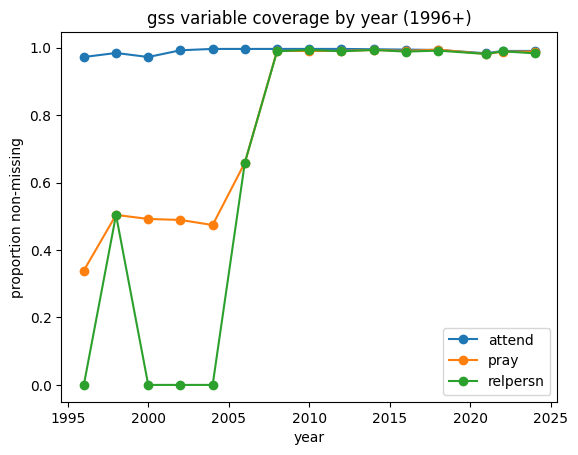

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# variables to check
vars_to_check = ["attend", "pray", "relpersn"]

# ensure column names are lowercase (safe if already lowercase)
df_96.columns = df_96.columns.str.lower()

# group by year and compute diagnostics
summary = df_96.groupby("year")[vars_to_check].agg(["count", "size"])

# compute proportion non-missing
prop_non_missing = df_96.groupby("year")[vars_to_check].apply(lambda x: x.notna().mean())

# combine into one table
coverage_table = prop_non_missing.round(3)

print("Proportion of non-missing values by year:")
print(coverage_table)

print("\nOverall completeness across all years:")
print(df_96[vars_to_check].notna().mean().round(3))

# optional quick visual check
coverage_table.plot(marker="o")
plt.ylabel("proportion non-missing")
plt.title("gss variable coverage by year (1996+)")
plt.show()

In [21]:
# Step 1 - Standardize within year
CORE = ["attend", "pray"]

for c in CORE:
    df_96[c + "_z"] = df_96.groupby("year")[c].transform(
        lambda x: (x - x.mean()) / x.std(ddof=0)
    )

# Step 2 - Reverse pray only
df_96["pray_z"] = -df_96["pray_z"]

# Step 3 - Build the religiosity index
Z = ["attend_z", "pray_z"]
df_96["religiosity_index"] = df_96[Z].mean(axis=1)

C:\Users\honor\AppData\Local\Temp\ipykernel_20356\2066666036.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_96[c + "_z"] = df_96.groupby("year")[c].transform(
C:\Users\honor\AppData\Local\Temp\ipykernel_20356\2066666036.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_96[c + "_z"] = df_96.groupby("year")[c].transform(
C:\Users\honor\AppData\Local\Temp\ipykernel_20356\2066666036.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

In [22]:
df_96["religiosity_index"].describe()

count    43050.000000
mean         0.000048
std          0.903049
min         -2.110899
25%         -0.759126
50%          0.008106
75%          0.817824
max          1.850962
Name: religiosity_index, dtype: float64